In [ ]:
import pandas as pd
df = pd.read_csv('NEW_lstm_training_data.csv')
print(f"✓ Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"✓ Has Model A: {'sentiment_a_mean' in df.columns}")
print(f"✓ Has Model B: {'sentiment_b_mean' in df.columns}")
print(f"✓ Has Model C: {'sentiment_c_mean' in df.columns}")
print(f"\nFirst 3 rows:")
print(df.head(3))


✓ Loaded 91 rows, 37 columns
✓ Has Model A: True
✓ Has Model B: True
✓ Has Model C: True

First 3 rows:
         date  tweet_count  sentiment_a_mean  sentiment_a_std  \
0  2021-09-01        11789          0.152091         0.402729   
1  2021-09-02        14339          0.155928         0.393780   
2  2021-09-03        13665          0.148599         0.390301   

   sentiment_a_median  sentiment_a_min  sentiment_a_max  sentiment_b_mean  \
0                 0.0          -0.9971           0.9880          0.167733   
1                 0.0          -0.9960           0.9914          0.173264   
2                 0.0          -0.9921           0.9849          0.164438   

   sentiment_b_std  sentiment_b_median  ...          high           low  \
0         0.410203                 0.0  ...  49111.089844  46562.437500   
1         0.402383                 0.0  ...  50343.421875  48652.320312   
2         0.398577                 0.0  ...  50982.273438  48386.085938   

          close       vol

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# FEATURE SELECTION & SCALING


df = pd.read_csv('NEW_lstm_training_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.fillna(0)  # day-1 price_change is NaN only

print(f"\n✓ Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"  Date range: {df['date'].min().date()} to {df['date'].max().date()}")

# Features we actually feed the LSTM
# Each model gets 5 inputs: close, volume, price_ma_7, price_change_pct + its own sentiment
cols_to_scale = [
    'close', 'volume', 'price_ma_7', 'price_change_pct', 'price_volatility_7',
    'sentiment_a_mean', 'sentiment_b_mean', 'sentiment_c_mean'
]

# Scale everything to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"\n✓ Scaled {len(cols_to_scale)} features to [0, 1]:")
for col in cols_to_scale:
    print(f"    {col:30s}  [{df[col].min():>12.4f}, {df[col].max():>12.4f}]")

#Target is scaled close price
print(f"\n✓ Target variable: close (scaled)")
print(f"  Real price range: ${df['close'].min():,.2f} – ${df['close'].max():,.2f}")



✓ Loaded 91 rows, 37 columns
  Date range: 2021-09-01 to 2021-11-30

✓ Scaled 8 features to [0, 1]:
    close                           [  40693.6758,   67566.8281]
    volume                          [24726754302.0000, 65210059683.0000]
    price_ma_7                      [  42484.3449,   65510.8795]
    price_change_pct                [    -11.0622,       9.8789]
    price_volatility_7              [      0.0000,    3580.6565]
    sentiment_a_mean                [      0.0807,       0.1816]
    sentiment_b_mean                [      0.0853,       0.2072]
    sentiment_c_mean                [      0.1004,       0.2476]

✓ Target variable: close (scaled)
  Real price range: $40,693.68 – $67,566.83


In [ ]:

# WINDOWING AND TRAIN/TEST SPLIT


TIMESTEPS = 3  # 3-day lookback window

# Each model gets 5 features: 4 shared price features + its own sentiment
features_A = ['close', 'volume', 'price_ma_7', 'price_change_pct', 'sentiment_a_mean']
features_B = ['close', 'volume', 'price_ma_7', 'price_change_pct', 'sentiment_b_mean']
features_C = ['close', 'volume', 'price_ma_7', 'price_change_pct', 'sentiment_c_mean']
TARGET = 'close'

def create_windows(data, feature_cols, target_col, window_size=3):
    """Create sliding windows: X = [t-3, t-2, t-1], y = [t]"""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[feature_cols].iloc[i:i+window_size].values)
        y.append(data[target_col].iloc[i + window_size])
    return np.array(X), np.array(y)

def temporal_split(X, y, train_ratio=0.7):
    """70/30 split — NO shuffling, time order preserved"""
    split = int(len(X) * train_ratio)
    return X[:split], X[split:], y[:split], y[split:]

# Build windows for all 3 models
X_A, y_A = create_windows(df_scaled, features_A, TARGET, TIMESTEPS)
X_B, y_B = create_windows(df_scaled, features_B, TARGET, TIMESTEPS)
X_C, y_C = create_windows(df_scaled, features_C, TARGET, TIMESTEPS)

#  Split
X_A_train, X_A_test, y_A_train, y_A_test = temporal_split(X_A, y_A)
X_B_train, X_B_test, y_B_train, y_B_test = temporal_split(X_B, y_B)
X_C_train, X_C_test, y_C_train, y_C_test = temporal_split(X_C, y_C)

# Print summary
print(f"\n✓ Window size: {TIMESTEPS} days")
print(f"  Total samples: {len(X_A)}  (91 days - {TIMESTEPS} = {len(X_A)})")
print(f"\n  Train / Test split (70/30):")
print(f"    Train: {len(X_A_train)} samples")
print(f"    Test:  {len(X_A_test)} samples")
print(f"\n  Shape check (all models identical structure):")
print(f"    X_train: {X_A_train.shape}  → (samples, timesteps, features)")
print(f"    X_test:  {X_A_test.shape}")
print(f"    y_train: {y_A_train.shape}")
print(f"    y_test:  {y_A_test.shape}")
print(f"\n  Features per model:")
print(f"    A: {features_A}")
print(f"    B: {features_B}")
print(f"    C: {features_C}")



✓ Window size: 3 days
  Total samples: 88  (91 days - 3 = 88)

  Train / Test split (70/30):
    Train: 61 samples
    Test:  27 samples

  Shape check (all models identical structure):
    X_train: (61, 3, 5)  → (samples, timesteps, features)
    X_test:  (27, 3, 5)
    y_train: (61,)
    y_test:  (27,)

  Features per model:
    A: ['close', 'volume', 'price_ma_7', 'price_change_pct', 'sentiment_a_mean']
    B: ['close', 'volume', 'price_ma_7', 'price_change_pct', 'sentiment_b_mean']
    C: ['close', 'volume', 'price_ma_7', 'price_change_pct', 'sentiment_c_mean']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# BUILDING LSTM MODELS


TIMESTEPS = 3

def build_lstm(n_features, name):
    """LSTM(32) → Dropout → LSTM(16) → Dropout → Dense(1)"""
    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=(TIMESTEPS, n_features), name=f'{name}_lstm1'),
        Dropout(0.2),
        LSTM(16, return_sequences=False, name=f'{name}_lstm2'),
        Dropout(0.2),
        Dense(1, name=f'{name}_output')
    ], name=name)
    model.compile(optimizer='adam', loss='mse')
    return model

# Build all 3
model_A = build_lstm(5, 'LSTM_A')
model_B = build_lstm(5, 'LSTM_B')
model_C = build_lstm(5, 'LSTM_C')

for label, model in [('A (Baseline)', model_A), ('B (Crypto)', model_B), ('C (Intensity)', model_C)]:
    print(f"\n--- Model {label} ---")
    model.summary()



--- Model A (Baseline) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_A_lstm1 (LSTM)             │ (None, 3, 32)          │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_A_lstm2 (LSTM)             │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_A_output (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,017 (31.32 KB)

...

Model: "LSTM_C"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_C_lstm1 (LSTM)             │ (None, 3, 32)          │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_C_lstm2 (LSTM)             │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_C_output (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,017 (31.32 KB)

 Trainable params: 8,017 (31.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# TRAIN ALL 3 LSTM MODELS

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

histories = {}

for label, model, X_tr, X_te, y_tr, y_te in [
    ('A (Baseline)',  model_A, X_A_train, X_A_test, y_A_train, y_A_test),
    ('B (Crypto)',    model_B, X_B_train, X_B_test, y_B_train, y_B_test),
    ('C (Intensity)', model_C, X_C_train, X_C_test, y_C_train, y_C_test)
]:
    print(f"\n- Training Model {label} ")
    history = model.fit(
        X_tr, y_tr,
        epochs=200,
        batch_size=4,
        validation_data=(X_te, y_te),
        callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
        verbose=0
    )
    histories[label] = history
    best_epoch = len(history.history['loss'])
    print(f"  ✓ Stopped at epoch {best_epoch}")
    print(f"    Train loss: {history.history['loss'][-1]:.6f}")
    print(f"    Val loss:   {history.history['val_loss'][-1]:.6f}")






- Training Model A (Baseline) 
  ✓ Stopped at epoch 157
    Train loss: 0.009028
    Val loss:   0.004183

- Training Model B (Crypto) 
  ✓ Stopped at epoch 173
    Train loss: 0.007909
    Val loss:   0.004677

- Training Model C (Intensity) 
  ✓ Stopped at epoch 195
    Train loss: 0.008715
    Val loss:   0.006522


In [ ]:
import numpy as np
from scipy import stats

# EVALUATE & COMPARE

def inverse_price(scaled_values):
    """Inverse transform scaled close prices back to real USD"""
    # close is index 0 in cols_to_scale
    dummy = np.zeros((len(scaled_values), len(cols_to_scale)))
    dummy[:, 0] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

#  Predictions
y_A_pred = model_A.predict(X_A_test, verbose=0).flatten()
y_B_pred = model_B.predict(X_B_test, verbose=0).flatten()
y_C_pred = model_C.predict(X_C_test, verbose=0).flatten()

#  Inverse transform back to real prices
actual   = inverse_price(y_A_test)   # same actual for all
pred_A   = inverse_price(y_A_pred)
pred_B   = inverse_price(y_B_pred)
pred_C   = inverse_price(y_C_pred)

# Metrics function
def compute_metrics(actual, predicted):
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae  = np.mean(np.abs(actual - predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2   = 1 - (ss_res / ss_tot)
    # Directional accuracy (did it predict up/down correctly?)
    dir_acc = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted))) * 100
    return rmse, mae, mape, r2, dir_acc

mA = compute_metrics(actual, pred_A)
mB = compute_metrics(actual, pred_B)
mC = compute_metrics(actual, pred_C)

#Print comparison table
print(f"\n{'Metric':<22} {'Model A':>14} {'Model B':>14} {'Model C':>14}")
print("-" * 64)
labels = ['RMSE ($)', 'MAE ($)', 'MAPE (%)', 'R²', 'Dir. Accuracy (%)']
for i, label in enumerate(labels):
    fmt = lambda v: f"{v:.4f}" if i == 3 else f"{v:.2f}"
    print(f"{label:<22} {fmt(mA[i]):>14} {fmt(mB[i]):>14} {fmt(mC[i]):>14}")

#Paired t-tests on absolute errors
print(f"\n Paired t-tests (|prediction error|) ")
err_A = np.abs(actual - pred_A)
err_B = np.abs(actual - pred_B)
err_C = np.abs(actual - pred_C)

t_AB, p_AB = stats.ttest_rel(err_A, err_B)
t_BC, p_BC = stats.ttest_rel(err_B, err_C)
t_AC, p_AC = stats.ttest_rel(err_A, err_C)

print(f"  A vs B: t={t_AB:+.4f}, p={p_AB:.4f}  {'* significant' if p_AB < 0.05 else 'ns'}")
print(f"  B vs C: t={t_BC:+.4f}, p={p_BC:.4f}  {'* significant' if p_BC < 0.05 else 'ns'}")
print(f"  A vs C: t={t_AC:+.4f}, p={p_AC:.4f}  {'* significant' if p_AC < 0.05 else 'ns'}")

# Best model
r2s = {'A (Baseline)': mA[3], 'B (Crypto)': mB[3], 'C (Intensity)': mC[3]}
best = max(r2s, key=r2s.get)
print(f"\n✓ Best R²: Model {best} ({r2s[best]:.4f})")



Metric                        Model A        Model B        Model C
----------------------------------------------------------------
RMSE ($)                      1719.23        1760.97        1777.68
MAE ($)                       1261.18        1327.28        1320.32
MAPE (%)                         2.10           2.20           2.19
R²                             0.7966         0.7866         0.7825
Dir. Accuracy (%)               38.46          42.31          42.31

 Paired t-tests (|prediction error|) 
  A vs B: t=-1.2561, p=0.2203  ns
  B vs C: t=+0.1195, p=0.9058  ns
  A vs C: t=-0.7966, p=0.4329  ns

✓ Best R²: Model A (Baseline) (0.7966)


/tmp/ipykernel_5108/985433106.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([actual - pred_A, actual - pred_B, actual - pred_C],


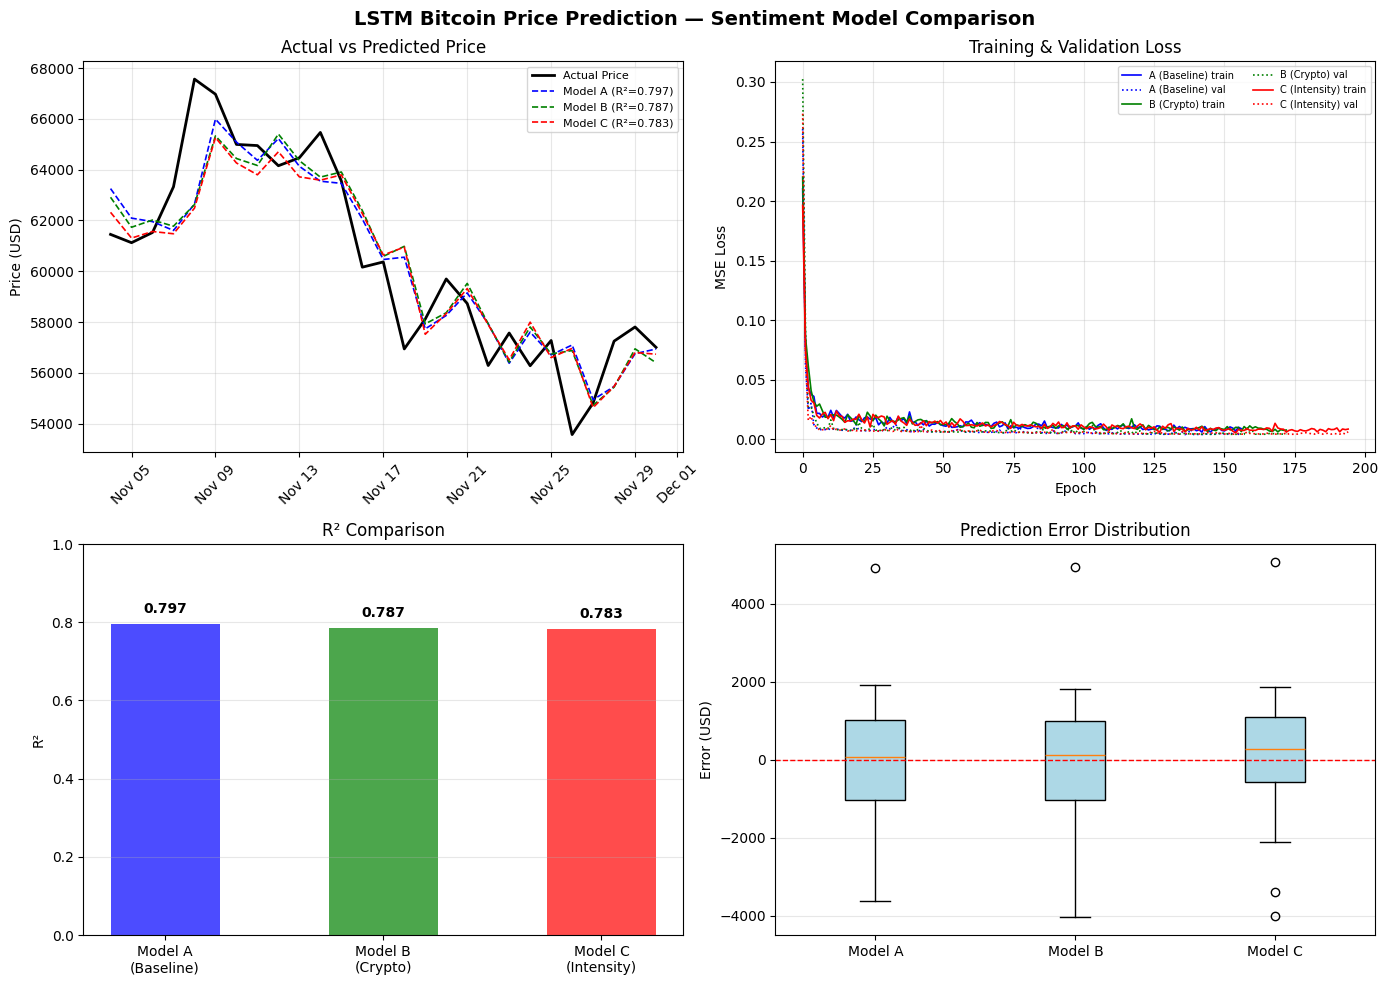

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Test dates: windowing shifts by 3, train=61, so test predicts rows 64–90
test_dates = pd.to_datetime(df['date'].iloc[64:91])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTM Bitcoin Price Prediction — Sentiment Model Comparison', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted
ax = axes[0, 0]
ax.plot(test_dates, actual,  color='black', linewidth=2, label='Actual Price')
ax.plot(test_dates, pred_A,  color='blue',  linewidth=1.2, linestyle='--', label=f'Model A (R²={mA[3]:.3f})')
ax.plot(test_dates, pred_B,  color='green', linewidth=1.2, linestyle='--', label=f'Model B (R²={mB[3]:.3f})')
ax.plot(test_dates, pred_C,  color='red',   linewidth=1.2, linestyle='--', label=f'Model C (R²={mC[3]:.3f})')
ax.set_title('Actual vs Predicted Price')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

#  Plot 2: Training & Validation Loss
ax = axes[0, 1]
colors = {'A (Baseline)': 'blue', 'B (Crypto)': 'green', 'C (Intensity)': 'red'}
for label, hist in histories.items():
    c = colors[label]
    ax.plot(hist.history['loss'],     color=c, linewidth=1.2,            label=f'{label} train')
    ax.plot(hist.history['val_loss'], color=c, linewidth=1.2, linestyle=':', label=f'{label} val')
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

#  Plot 3: Metrics Bar Chart
ax = axes[1, 0]
x = np.arange(3)
width = 0.25
r2_vals = [mA[3], mB[3], mC[3]]
bars = ax.bar(x, r2_vals, width=0.5, color=['blue', 'green', 'red'], alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(['Model A\n(Baseline)', 'Model B\n(Crypto)', 'Model C\n(Intensity)'])
ax.set_ylabel('R²')
ax.set_title('R² Comparison')
ax.set_ylim(0, 1.0)
ax.axhline(y=0, color='black', linewidth=0.5)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Prediction Errors
ax = axes[1, 1]
ax.boxplot([actual - pred_A, actual - pred_B, actual - pred_C],
           labels=['Model A', 'Model B', 'Model C'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.axhline(y=0, color='red', linewidth=1, linestyle='--')
ax.set_title('Prediction Error Distribution')
ax.set_ylabel('Error (USD)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=300, bbox_inches='tight')
plt.show()